In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torchvision.transforms as transforms


In [2]:
#Dataset
class CelebALandmarks(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, "img_align_celeba")
        self.transform = transform

        partition_file = os.path.join(root_dir, "list_eval_partition.txt")
        landmark_file = os.path.join(root_dir,"landmarks", "list_landmarks_align_celeba.txt")

        self.partition = {}
        with open(partition_file, "r") as f:
            for line in f:
                name, p = line.strip().split()
                self.partition[name] = int(p)

        split_map = {"train": 0, "val": 1, "test": 2}
        self.target_split = split_map[split]

        self.samples = []
        with open(landmark_file, "r") as f:
            lines = f.readlines()

        lines = lines[2:]

        for line in lines:
            parts = line.strip().split()
            img_name = parts[0]
            coords = list(map(float, parts[1:]))

            if self.partition[img_name] == self.target_split:
                self.samples.append((img_name, coords))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, coords = self.samples[idx]

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        w, h = image.size

        landmarks = torch.tensor(coords, dtype=torch.float32).view(-1, 2)

        landmarks[:, 0] /= w
        landmarks[:, 1] /= h

        if self.transform:
            image = self.transform(image)

        return image, landmarks.view(-1)  # shape: (10,)


transform = transforms.Compose([
    transforms.ToTensor(),
])


data_root = "/home/toru2/Amara/Deep_learning/dl_lab345.ipynb/dataset"

train_dataset = CelebALandmarks(root_dir=data_root, split="train", transform=transform)
test_dataset  = CelebALandmarks(root_dir=data_root, split="test", transform=transform)
val_dataset   = CelebALandmarks(root_dir=data_root, split="val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)



In [3]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")  
print(f"Number of test samples: {len(test_dataset)}")

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training samples: 162770
Number of validation samples: 19867
Number of test samples: 19962
Number of training batches: 1272
Number of validation batches: 156
Number of test batches: 156


Image shape: torch.Size([3, 218, 178])
Landmarks shape: torch.Size([10])


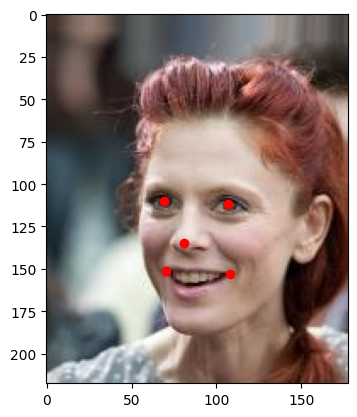

In [4]:
#Data set verification
import matplotlib.pyplot as plt

img, lm = train_dataset[1]

print(f"Image shape: {img.shape}")
print(f"Landmarks shape: {lm.shape}")

img_np = img.permute(1, 2, 0).numpy()
lm = lm.view(-1, 2)

h, w = img_np.shape[:2]

plt.imshow(img_np)
plt.scatter(lm[:, 0] * w, lm[:, 1] * h, c='r')
plt.show()

In [7]:
#block
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_chanels, **kwargs):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_chanels, **kwargs)
        self.bn = nn.BatchNorm2d(out_chanels)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))


class InceptionBlock(nn.Module):
    def __init__(
        self, in_channels, out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool
    ):

        super(InceptionBlock, self).__init__()
        self.branch1 = ConvBlock(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, red_3x3, kernel_size=1, padding=0),
            ConvBlock(red_3x3, out_3x3, kernel_size=3, padding=1),
        )
        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, red_5x5, kernel_size=1),
            ConvBlock(red_5x5, out_5x5, kernel_size=5, padding=2),
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            ConvBlock(in_channels, out_pool, kernel_size=1),
        )

    def forward(self, x):
        branches = (self.branch1, self.branch2, self.branch3, self.branch4)
        return torch.cat([branch(x) for branch in branches], 1)

In [8]:
class InceptionModel(nn.Module):
    def __init__(self, aux=False, residual=True, num_classes=10):
        super(InceptionModel, self).__init__()
        self.aux = aux
        self.residual = residual

        self.conv1 = ConvBlock(3, 32, kernel_size=3, stride=2, padding=1)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = ConvBlock(32, 64, kernel_size=3, stride=1, padding=1)

        self.incept3a = InceptionBlock(64, 32, 32, 64, 16, 32, 32)
        self.incept3b = InceptionBlock(160, 64, 64, 96, 32, 64, 64)

        self.incept4a = InceptionBlock(288, 96, 64, 128, 32, 64, 64)
        self.incept4b = InceptionBlock(352, 96, 64, 128, 32, 64, 64)

        self.incept5a = InceptionBlock(352, 128, 96, 160, 32, 96, 96)

        self.dropout = nn.Dropout(p=0.3)

        self.fc = nn.Linear(480, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        x = self.conv2(x)
        x = self.maxpool(x)

        x = self.incept3a(x)
        x = self.incept3b(x)

        x = self.maxpool(x)

        x = self.incept4a(x)
        x = self.incept4b(x)

        x = self.maxpool(x)

        x = self.incept5a(x)

        x = F.adaptive_avg_pool2d(x, (1, 1))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        x = torch.sigmoid(x)

        return x  

In [9]:
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InceptionModel(aux=False, residual=True, num_classes=10).to(device)

stats = summary(
    model,
    input_size=(1, 3, 218, 178),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    verbose=1
)

print("Total params:", stats.total_params)
print("Trainable params:", stats.trainable_params)

param_mb_fp32 = stats.total_params * 4 / (1024 ** 2)
print(f"Approx param size FP32 (MB): {param_mb_fp32:.2f}")

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
InceptionModel                           [1, 3, 218, 178]          [1, 10]                   --                        True
├─ConvBlock: 1-1                         [1, 3, 218, 178]          [1, 32, 109, 89]          --                        True
│    └─Conv2d: 2-1                       [1, 3, 218, 178]          [1, 32, 109, 89]          896                       True
│    └─BatchNorm2d: 2-2                  [1, 32, 109, 89]          [1, 32, 109, 89]          64                        True
├─MaxPool2d: 1-2                         [1, 32, 109, 89]          [1, 32, 54, 44]           --                        --
├─ConvBlock: 1-3                         [1, 32, 54, 44]           [1, 64, 54, 44]           --                        True
│    └─Conv2d: 2-3                       [1, 32, 54, 44]           [1, 64, 54, 44]           18,496                    True
│    

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

sanity_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=0)
images, targets = next(iter(sanity_loader))
images = images.to(device).float()
targets = targets.to(device).float()

Using device: cuda


In [9]:
import itertools
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------- reproducibility ----------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

images, targets = next(iter(sanity_loader))
images = images.to(device).float()
targets = targets.to(device).float()

# ---------------- search space ----------------
# search_space = {
#     "lr": [1e-2, 3e-3, 1e-3, 3e-4, 1e-4],
#     "optimizer": ["Adam", "AdamW", "SGD"],
#     "weight_decay": [0.0, 1e-5, 1e-4],
#     "loss": ["MSE", "SmoothL1"],
#     "dropout": [0.0, 0.1, 0.2],
# }

# max_steps = 1500
# target_loss = 1e-4
# print_every = 200

search_space = {
    "lr": [1e-3, 3e-4, 1e-4],         # 3
    "optimizer": ["AdamW", "Adam"],   # 2
    "weight_decay": [0.0, 1e-4],      # 2
    "loss": ["SmoothL1", "MSE"],      # 2
    "dropout": [0.0, 0.1],            # 2
}
# total = 3*2*2*2*2 = 48 combos
max_steps = 1000
target_loss = 3e-4

def build_optimizer(name, params, lr, wd):
    if name == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=wd)
    if name == "AdamW":
        return optim.AdamW(params, lr=lr, weight_decay=wd)
    if name == "SGD":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    raise ValueError(f"Unknown optimizer: {name}")

def build_loss(name):
    if name == "MSE":
        return nn.MSELoss()
    if name == "SmoothL1":
        return nn.SmoothL1Loss()
    raise ValueError(f"Unknown loss: {name}")

results = []
all_combos = list(itertools.product(
    search_space["lr"],
    search_space["optimizer"],
    search_space["weight_decay"],
    search_space["loss"],
    search_space["dropout"],
))

print(f"Total combos: {len(all_combos)}")

for i, (lr, opt_name, wd, loss_name, drop_p) in enumerate(all_combos, 1):
    set_seed(42)
    model = InceptionModel().to(device)

    if hasattr(model, "dropout"):
        model.dropout.p = drop_p

    criterion = build_loss(loss_name)
    optimizer = build_optimizer(opt_name, model.parameters(), lr, wd)

    model.train()
    best_loss = float("inf")
    final_loss = None
    reached_target = False
    step_reached = None
    start = time.time()

    for step in range(1, max_steps + 1):
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        loss_val = loss.item()
        final_loss = loss_val
        if loss_val < best_loss:
            best_loss = loss_val

        if loss_val <= target_loss:
            reached_target = True
            step_reached = step
            break

    elapsed = time.time() - start

    # ranking score: prioritize reaching target, then lower loss, then fewer steps
    score = (
        (0 if reached_target else 1),
        best_loss,
        step_reached if step_reached is not None else max_steps + 1
    )

    results.append({
        "lr": lr,
        "optimizer": opt_name,
        "weight_decay": wd,
        "loss": loss_name,
        "dropout": drop_p,
        "best_loss": best_loss,
        "final_loss": final_loss,
        "reached_target": reached_target,
        "step_reached": step_reached if step_reached is not None else -1,
        "time_sec": round(elapsed, 2),
        "score": score
    })

    print(
        f"[{i:03d}/{len(all_combos)}] "
        f"opt={opt_name:<5} lr={lr:<7g} wd={wd:<7g} loss={loss_name:<8} drop={drop_p:.1f} "
        f"| best={best_loss:.6f} reached={reached_target} step={step_reached}"
    )

    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ---------------- summarize ----------------
df = pd.DataFrame(results).sort_values(by=["score", "time_sec"]).reset_index(drop=True)
df = df.drop(columns=["score"])

print("\nTop 10 combinations:")
print(df.head(10))

best = df.iloc[0].to_dict()
print("\nBest one-batch combo:")
print(best)

Total combos: 48
[001/48] opt=AdamW lr=0.001   wd=0       loss=SmoothL1 drop=0.0 | best=0.000298 reached=True step=32
[002/48] opt=AdamW lr=0.001   wd=0       loss=SmoothL1 drop=0.1 | best=0.000290 reached=True step=528
[003/48] opt=AdamW lr=0.001   wd=0       loss=MSE      drop=0.0 | best=0.000298 reached=True step=42
[004/48] opt=AdamW lr=0.001   wd=0       loss=MSE      drop=0.1 | best=0.000362 reached=False step=None
[005/48] opt=AdamW lr=0.001   wd=0.0001  loss=SmoothL1 drop=0.0 | best=0.000295 reached=True step=32
[006/48] opt=AdamW lr=0.001   wd=0.0001  loss=SmoothL1 drop=0.1 | best=0.000281 reached=True step=689
[007/48] opt=AdamW lr=0.001   wd=0.0001  loss=MSE      drop=0.0 | best=0.000289 reached=True step=42
[008/48] opt=AdamW lr=0.001   wd=0.0001  loss=MSE      drop=0.1 | best=0.000442 reached=False step=None
[009/48] opt=Adam  lr=0.001   wd=0       loss=SmoothL1 drop=0.0 | best=0.000293 reached=True step=32
[010/48] opt=Adam  lr=0.001   wd=0       loss=SmoothL1 drop=0.1 | 

KeyboardInterrupt: 

best

[044/48] opt=Adam  lr=0.0001  wd=0       loss=MSE      drop=0.1 | best=0.000570 reached=False step=None

[045/48] opt=Adam  lr=0.0001  wd=0.0001  loss=SmoothL1 drop=0.0 | best=0.000230 reached=True step=32

[048/48] opt=Adam  lr=0.0001  wd=0.0001  loss=MSE      drop=0.1 | best=0.000559 reached=False step=None

Top 10 combinations:
       lr optimizer  weight_decay      loss  dropout  best_loss  final_loss  \
0  0.0003     AdamW        0.0000       MSE      0.0   0.000186    0.000186   
1  0.0003      Adam        0.0001       MSE      0.0   0.000188    0.000188   
2  0.0003      Adam        0.0000       MSE      0.0   0.000192    0.000192   
3  0.0003     AdamW        0.0001       MSE      0.0   0.000192    0.000192   
4  0.0001     AdamW        0.0000  SmoothL1      0.0   0.000229    0.000229   
5  0.0010     AdamW        0.0000       MSE      0.0   0.000230    0.000230   
6  0.0001      Adam        0.0001  SmoothL1      0.0   0.000230    0.000230   
7  0.0001      Adam        0.0000  SmoothL1      0.0   0.000234    0.000234   
8  0.0010      Adam        0.0000       MSE      0.0   0.000235    0.000235   
9  0.0010      Adam        0.0001  SmoothL1      0.0   0.000236    0.000236   

   reached_target  step_reached  time_sec  
0            True            34      1.22  
1            True            34      1.22  
2            True            34      1.22  
3            True            34      1.22  
4            True            32      1.15  
5            True            35      1.25  
6            True            32      1.15  
7            True            32      1.14  
8            True            35      1.25  
9            True            27      0.97  

Best one-batch combo:
{'lr': 0.0003, 'optimizer': 'AdamW', 'weight_decay': 0.0, 'loss': 'MSE', 'dropout': 0.0, 'best_loss': 0.00018631819693837315, 'final_loss': 0.00018631819693837315, 'reached_target': True, 'step_reached': 34, 'time_sec': 1.22}